# Theoretical probability of error for QPSK modulation

Let us analyse theoretical probability of error for QPSK modulation. First let us install all dependencies.

In [1]:
pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


Import them

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

Quick and dirty piece of code that computes QPSK probability of error and compares it with theoretical one

Processing SNR = 0dB
SNR = 0dB, number_of_errors = 76150, results = 0.15
Processing SNR = 1dB
SNR = 1dB, number_of_errors = 54298, results = 0.11
Processing SNR = 2dB
SNR = 2dB, number_of_errors = 36992, results = 0.07
Processing SNR = 3dB
SNR = 3dB, number_of_errors = 22324, results = 0.04
Processing SNR = 4dB
SNR = 4dB, number_of_errors = 12584, results = 0.03
Processing SNR = 5dB
SNR = 5dB, number_of_errors = 5906, results = 0.01
Processing SNR = 6dB
SNR = 6dB, number_of_errors = 2374, results = 0.00
Processing SNR = 7dB
SNR = 7dB, number_of_errors = 728, results = 0.00
Processing SNR = 8dB
SNR = 8dB, number_of_errors = 197, results = 0.00
Processing SNR = 9dB
SNR = 9dB, number_of_errors = 43, results = 0.00


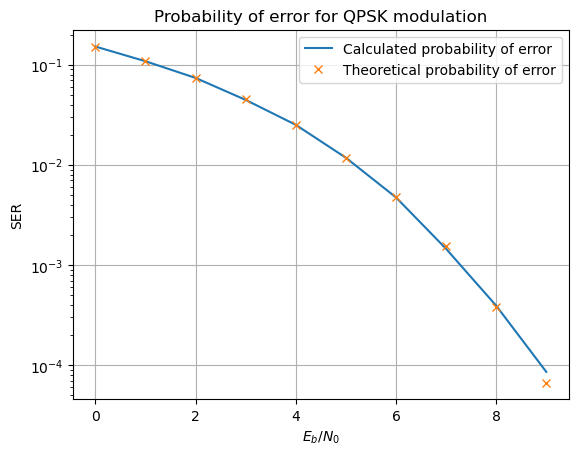

In [4]:
snr_min = 0
snr_max = 10
snr_step = 1
number_of_iterations = 500000

actual_results = {}
theoretical_results = {}
for snr in range(snr_min, snr_max, snr_step):
    print(f"Processing SNR = {snr}dB")
    # Convert SNR to linear scale
    snr_linear = 10 ** (snr / 10)
    number_of_errors = 0
    for idx in range(number_of_iterations):
        # Generate QPSK symbol and normalise it
        re_x = np.random.randint(0, 2) * 2 - 1
        im_x = np.random.randint(0, 2) * 2 - 1
        x = 1 / np.sqrt(2) * (re_x + 1.0j * im_x)
        # Generate noise
        sigma = 1 / np.sqrt(4 * snr_linear)
        noise = sigma * np.random.randn() + 1.0j * sigma * np.random.randn()
        y = x + noise
        # Count number of errors
        number_of_errors += np.sign(np.real(y)) != np.sign(np.real(x)) or np.sign(np.imag(y)) != np.sign(np.imag(x))
    actual_results[snr] = number_of_errors / number_of_iterations
    p = 0.5 * erfc(np.sqrt(snr_linear))
    theoretical_results[snr] = 1 - (1 - p) ** 2
    print(f"SNR = {snr}dB, number_of_errors = {number_of_errors}, results = {actual_results[snr]:.2f}")

# Plot results
plt.figure()
plt.semilogy(actual_results.keys(), actual_results.values(), label = 'Calculated probability of error')
plt.semilogy(theoretical_results.keys(), theoretical_results.values(), 'x', label = 'Theoretical probability of error')
plt.xlabel('$E_{b}/N_{0}$')
plt.ylabel('SER')
plt.title('Probability of error for QPSK modulation')
plt.legend()
plt.grid()
plt.show()